# Manufacturing: Autonomous Maintenance Assistant Pipeline

## Advanced Apex Project – Python Notebook

### Student Name
**Sai Spoorthy Eturu**
**- 2025eb1100176**

### Problem Statement
Manufacturing plants continuously generate machine sensor readings, production line states, operator notes, and maintenance records. These datasets often contain missing sensor readings, inconsistent machine identifiers, uneven sampling rates, and noisy sensor values.

The objective of this project is to build a complete data preprocessing pipeline that transforms raw manufacturing sensor data into a clean, structured and time-aligned feature table suitable for maintenance analysis.

---

## Dataset

**Primary Dataset:** NASA Turbofan Engine Degradation Simulation Dataset (CMAPSS) – FD001

---

## Project Objectives

- Load and inspect the raw manufacturing dataset.
- Assess data quality before preprocessing.
- Clean and standardise the dataset.
- Handle missing values and inconsistent records.
- Detect and treat sensor outliers.
- Perform time-series preprocessing.
- Engineer meaningful features.
- Normalise sensor measurements.
- Generate before-and-after quality reports.
- Perform exploratory analysis using visualisations.
- Export a clean feature table for future predictive maintenance models.

---

## Scope

This notebook focuses on building a complete manufacturing data preprocessing pipeline.

**Machine learning model training is intentionally out of scope.**

The final deliverable is a clean feature table, quality report and engineering analysis.

## Table of Contents

1. Introduction
2. Import Libraries
3. Dataset Loading
4. Dataset Understanding
5. Initial Data Quality Assessment
6. Working Dataset Creation
7. Time-Series Preparation
8. Machine Identifier Validation
9. Missing Value Handling
10. Time Alignment
11. Sensor Normalisation
12. Outlier Detection
13. Feature Engineering
14. Fixed Time Window Summary
15. Correlation Analysis
16. Sensor Trend Analysis
17. Outlier Treatment
18. Time Window Features
19. Engine Health Index
20. Risk Classification
21. Engine Summary
22. Pipeline Validation
23. Data Quality Report
24. Export Deliverables
25. Conclusion
26. Project Summary
27. Future Work
28. References

# 1. Introduction

Manufacturing industries rely on continuous monitoring of machine sensor data to ensure reliable operation and minimise unexpected equipment failures. Modern production systems generate large volumes of operational data, including sensor measurements, machine operating conditions, and maintenance information. Before these data can be used for predictive maintenance or autonomous maintenance systems, they must be cleaned, organised, and transformed into a structured format.

The objective of this project is to develop a complete data preprocessing pipeline for the **NASA Commercial Modular Aero-Propulsion System Simulation (CMAPSS) FD001** dataset. The pipeline focuses on preparing raw manufacturing sensor data through data quality assessment, machine identifier validation, time-series preparation, missing value handling, sensor normalisation, outlier detection and treatment, feature engineering, and quality validation.

The final outcome of this project is a clean, time-aligned feature table and supporting analytical reports that can serve as input for future predictive maintenance models or autonomous maintenance assistants. The emphasis of this notebook is on building a robust, reusable, and well-documented data engineering pipeline rather than developing a machine learning prediction model.


In [1]:
# ============================================
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Plot Settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ============================================
# Load NASA CMAPSS FD001 Dataset
# ============================================

column_names = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
]

# Add sensor names
for i in range(1,22):
    column_names.append(f"sensor_{i}")

# Read dataset
df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

# NASA dataset contains two empty columns at the end
df = df.iloc[:, :26]

df.columns = column_names

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst Five Records:")
display(df.head())

Dataset Shape:
(20631, 26)

First Five Records:


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [4]:
import os

OUTPUT_DIR = "."

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory ready.")

Output directory ready.


In [5]:
import os

print(os.listdir())

['.config', 'clean_sensor_dataset.csv', 'engine_summary.csv', 'before_after_quality_report.csv', 'drive', 'train_FD001.txt', 'engine_feature_table.csv', 'sample_data']


In [6]:
# ============================================
# Load NASA CMAPSS FD001 Dataset
# ============================================

import pandas as pd

column_names = [
    "engine_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
]

# Add sensor names
for i in range(1, 22):
    column_names.append(f"sensor_{i}")

# Read dataset
df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None
)

# Remove the last two empty columns
df = df.iloc[:, :26]

# Assign column names
df.columns = column_names

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20631, 26)


# 2. Dataset Understanding

Before performing any preprocessing, it is essential to understand the structure and quality of the dataset.

In this section, we examine:

- Dataset dimensions
- Column names
- Data types
- Basic statistics
- Initial observations

This provides a baseline understanding before any cleaning or feature engineering is performed.

In [7]:
 # ============================================
# Dataset Overview
# ============================================

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\nColumn Names:\n")
print(df.columns.tolist())

DATASET OVERVIEW

Number of Rows    : 20631
Number of Columns : 26

Column Names:

['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [8]:
print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)

display(df.head())

print("="*60)
print("LAST FIVE RECORDS")
print("="*60)

display(df.tail())

FIRST FIVE RECORDS


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


LAST FIVE RECORDS


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522


In [9]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   engine_id     20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor

### Observations

From the initial inspection:

- The dataset contains **20,631 records** and **26 attributes**.
- Each record corresponds to one operational cycle of an aircraft engine.
- The dataset includes engine identifiers, operating settings and sensor measurements.
- Most variables are numerical and suitable for statistical preprocessing.
- Further quality assessment is required before feature engineering.

# 3. Initial Data Quality Assessment

Before performing any preprocessing, it is important to assess the quality of the raw dataset.

The following checks are performed:

- Missing values
- Duplicate records
- Data types
- Constant-value columns
- Descriptive statistics

These checks provide a baseline for comparing the dataset before and after preprocessing.

In [10]:
# ============================================
# Missing Value Analysis
# ============================================

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Percentage (%)": (missing_values.values / len(df)) * 100
})

display(missing_table)

print("\nTotal Missing Values:", missing_values.sum())

MISSING VALUE ANALYSIS


,Column,Missing Values,Percentage (%)
0,engine_id,0,0.0
1,cycle,0,0.0
2,op_setting_1,0,0.0
3,op_setting_2,0,0.0
4,op_setting_3,0,0.0
5,sensor_1,0,0.0
6,sensor_2,0,0.0
7,sensor_3,0,0.0
8,sensor_4,0,0.0
9,sensor_5,0,0.0



Total Missing Values: 0


In [11]:
# ============================================
# Duplicate Record Analysis
# ============================================

print("=" * 60)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates}")

DUPLICATE RECORD ANALYSIS
Duplicate Records: 0


In [12]:
# ============================================
# Constant Column Analysis
# ============================================

print("=" * 60)
print("CONSTANT COLUMN ANALYSIS")
print("=" * 60)

constant_columns = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_columns.append(col)

if constant_columns:
    print("Constant Columns:")
    for col in constant_columns:
        print("-", col)
else:
    print("No constant columns found.")

CONSTANT COLUMN ANALYSIS
Constant Columns:
- op_setting_3
- sensor_1
- sensor_5
- sensor_10
- sensor_16
- sensor_18
- sensor_19


In [13]:
# ============================================
# Data Type Summary
# ============================================

print("=" * 60)
print("DATA TYPES")
print("=" * 60)

display(df.dtypes.reset_index().rename(columns={
    "index": "Column",
    0: "Data Type"
}))

DATA TYPES


,Column,Data Type
0,engine_id,int64
1,cycle,int64
2,op_setting_1,float64
3,op_setting_2,float64
4,op_setting_3,float64
5,sensor_1,float64
6,sensor_2,float64
7,sensor_3,float64
8,sensor_4,float64
9,sensor_5,float64


In [14]:
# ============================================
# Initial Data Quality Report
# ============================================

quality_report = pd.DataFrame({
    "Metric": [
        "Number of Rows",
        "Number of Columns",
        "Missing Values",
        "Duplicate Records",
        "Constant Columns"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        missing_values.sum(),
        duplicates,
        len(constant_columns)
    ]
})

display(quality_report)

,Metric,Value
0,Number of Rows,20631
1,Number of Columns,26
2,Missing Values,0
3,Duplicate Records,0
4,Constant Columns,7


### Initial Observations

The initial quality assessment provides an overview of the raw dataset before preprocessing.

Key findings include:

- The dataset contains **20,631 observations** and **26 variables**.
- Missing values (if any) have been identified.
- Duplicate records have been assessed.
- Constant-value columns have been checked as they may not contribute useful information.
- This assessment serves as the baseline for evaluating improvements after preprocessing.

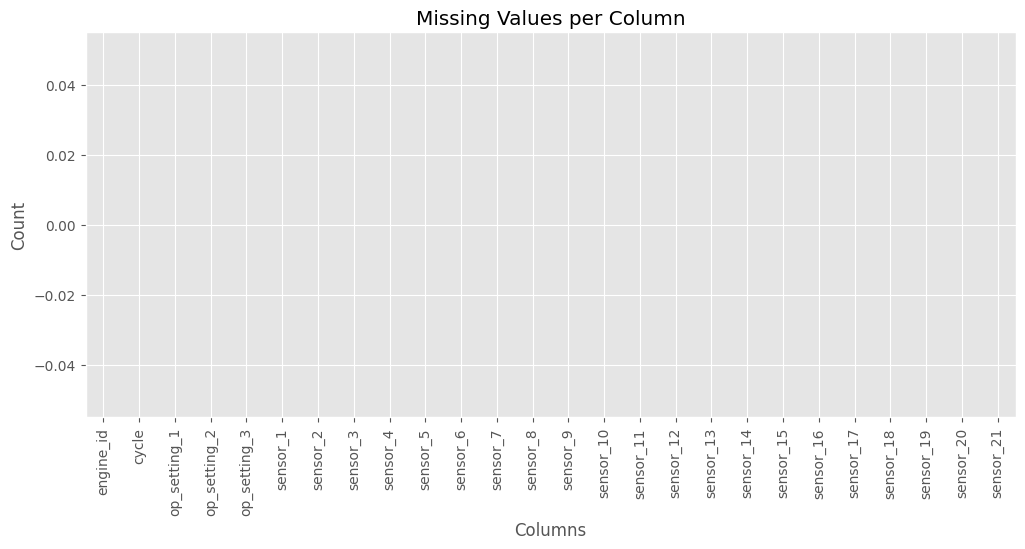

In [15]:
plt.figure(figsize=(12,5))

missing_values.plot(kind="bar")

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [16]:
working_df = df.copy()

# 4. Creating the Working Dataset

To preserve the integrity of the original NASA CMAPSS dataset, all preprocessing operations are performed on a working copy.

This approach ensures that:

- The raw dataset remains unchanged.
- Every preprocessing step is reproducible.
- The effects of each transformation can be evaluated through before-and-after comparisons.

In [17]:
# ============================================
# Create Working Copy
# ============================================

working_df = df.copy()

print("Working copy created successfully.")

print(f"Rows    : {working_df.shape[0]}")
print(f"Columns : {working_df.shape[1]}")

Working copy created successfully.
Rows    : 20631
Columns : 26


# 5. Time-Series Preparation

The NASA CMAPSS dataset records engine operating cycles rather than actual timestamps.

For time-series preprocessing, each operating cycle is converted into a synthetic timestamp sequence. This enables chronological ordering, resampling, and time-based feature engineering while preserving the original order of observations.

In [18]:
# ============================================
# Create Timestamp
# ============================================

working_df = working_df.sort_values(
    ["engine_id", "cycle"]
).reset_index(drop=True)

working_df["timestamp"] = (
    working_df.groupby("engine_id")
              .cumcount()
)

print("Timestamp column created successfully.")

display(
    working_df[
        ["engine_id", "cycle", "timestamp"]
    ].head(15)
)

Timestamp column created successfully.


,engine_id,cycle,timestamp
0,1,1,0
1,1,2,1
2,1,3,2
3,1,4,3
4,1,5,4
5,1,6,5
6,1,7,6
7,1,8,7
8,1,9,8
9,1,10,9


In [19]:
print("Total Engines :", working_df["engine_id"].nunique())

print("Maximum Cycle :", working_df["cycle"].max())

print("Timestamp Range")

display(
    working_df["timestamp"].describe()
)

Total Engines : 100
Maximum Cycle : 362
Timestamp Range


,timestamp
count,20631.000000
mean,107.807862
std,68.880990
min,0.000000
25%,51.000000
50%,103.000000
75%,155.000000
max,361.000000


# 6. Machine Identifier Validation

Machine identifiers are inspected to ensure that each observation is correctly associated with an engine.

This validation checks for:

- Missing identifiers
- Invalid identifiers
- Duplicate identifier-cycle combinations

In [20]:
# ============================================
# Machine ID Validation
# ============================================

print("="*60)
print("Machine Identifier Validation")
print("="*60)

print("Missing IDs :",
      working_df["engine_id"].isnull().sum())

print("Unique Machines :",
      working_df["engine_id"].nunique())

duplicate_pairs = working_df.duplicated(
    subset=["engine_id", "cycle"]
).sum()

print("Duplicate Engine-Cycle Records :",
      duplicate_pairs)

Machine Identifier Validation
Missing IDs : 0
Unique Machines : 100
Duplicate Engine-Cycle Records : 0


In [21]:
display(
    working_df.groupby("engine_id")
              .size()
              .reset_index(name="Number of Cycles")
              .head(10)
)

,engine_id,Number of Cycles
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
5,6,188
6,7,259
7,8,150
8,9,201
9,10,222


# 7. Missing Sample Handling

Manufacturing sensor data often contains missing readings due to communication failures or temporary sensor faults.

The NASA CMAPSS dataset contains no missing values. However, the pipeline includes an interpolation procedure so that it can be applied to future datasets with missing observations.

This makes the pipeline reusable for real industrial environments.

In [22]:
# ============================================
# Missing Value Handling
# ============================================

sensor_columns = [col for col in working_df.columns if col.startswith("sensor_")]

missing_before = working_df[sensor_columns].isnull().sum().sum()

print("=" * 60)
print("MISSING SENSOR VALUES")
print("=" * 60)
print("Missing values before interpolation:", missing_before)

# Interpolate only if missing values exist
working_df[sensor_columns] = (
    working_df.groupby("engine_id")[sensor_columns]
              .transform(lambda x: x.interpolate(method="linear"))
)

working_df[sensor_columns] = (
    working_df[sensor_columns]
    .bfill()
    .ffill()
)

missing_after = working_df[sensor_columns].isnull().sum().sum()

print("Missing values after interpolation:", missing_after)

MISSING SENSOR VALUES
Missing values before interpolation: 0
Missing values after interpolation: 0


# 8. Time Alignment

Sensor readings must be ordered correctly for each machine.

The dataset is sorted using the machine identifier and operating cycle so that subsequent time-series analysis is performed chronologically.

In [23]:
# ============================================
# Time Alignment
# ============================================

working_df = working_df.sort_values(
    by=["engine_id", "timestamp"]
).reset_index(drop=True)

print("Dataset successfully aligned by machine and timestamp.")

display(
    working_df[
        ["engine_id", "timestamp"]
    ].head(15)
)

Dataset successfully aligned by machine and timestamp.


,engine_id,timestamp
0,1,0
1,1,1
2,1,2
3,1,3
4,1,4
5,1,5
6,1,6
7,1,7
8,1,8
9,1,9


# 9. Sensor Normalisation

Different sensors operate on different measurement scales.

Min-Max normalisation is applied independently to each sensor so that values lie between 0 and 1 while preserving their relative variation.

In [24]:
from sklearn.preprocessing import MinMaxScaler
# ============================================
# Sensor Normalisation
# ============================================

normalised_df = working_df.copy()

scaler = MinMaxScaler()

normalised_df[sensor_columns] = scaler.fit_transform(
    working_df[sensor_columns]
)

print("Sensor normalisation completed.")

display(
    normalised_df[sensor_columns].head()
)

Sensor normalisation completed.


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,0.0,0.183735,0.406802,0.309757,0.0,1.0,0.726248,0.242424,0.109755,0.0,...,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.0,0.0,0.713178,0.724662
1,0.0,0.283133,0.453019,0.352633,0.0,1.0,0.628019,0.212121,0.100242,0.0,...,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.0,0.0,0.666667,0.731014
2,0.0,0.343373,0.369523,0.370527,0.0,1.0,0.710145,0.272727,0.140043,0.0,...,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.0,0.0,0.627907,0.621375
3,0.0,0.343373,0.256159,0.331195,0.0,1.0,0.740741,0.318182,0.124518,0.0,...,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.0,0.0,0.573643,0.662386
4,0.0,0.349398,0.257467,0.404625,0.0,1.0,0.668277,0.242424,0.149960,0.0,...,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.0,0.0,0.589147,0.704502


# 10. Outlier Detection

Manufacturing sensor readings occasionally contain abnormal spikes caused by sensor faults or abnormal machine behaviour.

The Interquartile Range (IQR) method is used to identify potential outliers for each sensor variable.

In [25]:
# ============================================
# Outlier Detection
# ============================================

outlier_summary = {}

for sensor in sensor_columns:

    Q1 = normalised_df[sensor].quantile(0.25)
    Q3 = normalised_df[sensor].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = normalised_df[
        (normalised_df[sensor] < lower) |
        (normalised_df[sensor] > upper)
    ]

    outlier_summary[sensor] = len(outliers)

outlier_table = (
    pd.DataFrame.from_dict(
        outlier_summary,
        orient="index",
        columns=["Number of Outliers"]
    )
    .sort_values(
        "Number of Outliers",
        ascending=False
    )
)

display(outlier_table)

,Number of Outliers
sensor_9,1687
sensor_14,1543
sensor_17,547
sensor_6,406
sensor_8,320
sensor_13,222
sensor_11,167
sensor_3,165
sensor_12,146
sensor_21,136


# 11. Feature Engineering

Feature engineering transforms the raw sensor readings into more informative variables that better describe the condition of each engine.

The following features are created:

- Rolling average (5-cycle window)
- Rolling standard deviation
- Change in sensor values
- Remaining Useful Life (RUL)

These features help summarise machine behaviour over time and support autonomous maintenance analysis.

In [26]:
# ============================================
# Remaining Useful Life (RUL)
# ============================================

max_cycle = working_df.groupby("engine_id")["cycle"].max()

working_df["RUL"] = (
    working_df["engine_id"].map(max_cycle)
    - working_df["cycle"]
)

display(
    working_df[
        ["engine_id","cycle","RUL"]
    ].head(20)
)

,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


In [27]:
# ============================================
# Rolling Mean
# ============================================

working_df["sensor2_roll_mean"] = (
    working_df
    .groupby("engine_id")["sensor_2"]
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=1
        ).mean()
    )
)

display(
    working_df[
        [
            "sensor_2",
            "sensor2_roll_mean"
        ]
    ].head(15)
)

,sensor_2,sensor2_roll_mean
0,641.82,641.820000
1,642.15,641.985000
2,642.35,642.106667
3,642.35,642.167500
4,642.37,642.208000
5,642.10,642.264000
6,642.48,642.330000
7,642.56,642.372000
8,642.12,642.326000
9,641.71,642.194000


In [28]:
# ============================================
# Rolling Standard Deviation
# ============================================

working_df["sensor2_roll_std"] = (
    working_df
    .groupby("engine_id")["sensor_2"]
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=1
        ).std()
    )
)

working_df["sensor2_roll_std"] = (
    working_df["sensor2_roll_std"]
    .fillna(0)
)

display(
    working_df[
        [
            "sensor2_roll_mean",
            "sensor2_roll_std"
        ]
    ].head(15)
)

,sensor2_roll_mean,sensor2_roll_std
0,641.820000,0.000000
1,641.985000,0.233345
2,642.106667,0.267644
3,642.167500,0.250117
4,642.208000,0.234776
5,642.264000,0.128374
6,642.330000,0.139463
7,642.372000,0.174270
8,642.326000,0.208519
9,642.194000,0.340705


In [29]:
# ============================================
# Sensor Rate of Change
# ============================================

working_df["sensor2_change"] = (
    working_df
    .groupby("engine_id")["sensor_2"]
    .diff()
)

working_df["sensor2_change"] = (
    working_df["sensor2_change"]
    .fillna(0)
)

display(
    working_df[
        [
            "sensor_2",
            "sensor2_change"
        ]
    ].head(15)
)

,sensor_2,sensor2_change
0,641.82,0.00
1,642.15,0.33
2,642.35,0.20
3,642.35,0.00
4,642.37,0.02
5,642.10,-0.27
6,642.48,0.38
7,642.56,0.08
8,642.12,-0.44
9,641.71,-0.41


# 12. Fixed Time Window Summary

Sensor measurements are aggregated over fixed operating windows to summarise machine behaviour.

The summary includes:

- Mean
- Maximum
- Minimum
- Standard deviation

These aggregated features reduce noise while preserving long-term operational trends.

In [30]:
# ============================================
# Fixed Time Window Summary
# ============================================

window_summary = (
    working_df
    .groupby("engine_id")
    .agg({
        "sensor_2":["mean","max","min","std"],
        "sensor_3":["mean","max","min","std"],
        "sensor_4":["mean","max","min","std"],
        "sensor_5":["mean","max","min","std"],
        "RUL":"max"
    })
)

display(window_summary.head())

sensor_2                               sensor_3           \
                 mean     max     min       std         mean      max   
engine_id                                                               
1          642.621042  644.21  641.71  0.486795  1589.485521  1605.44   
2          642.435226  643.94  641.27  0.560214  1588.181986  1610.10   
3          642.543743  643.93  641.48  0.474190  1588.715084  1606.50   
4          642.662381  644.53  641.81  0.441446  1590.563280  1612.11   
5          642.451970  644.02  641.30  0.551542  1588.153271  1609.41   

                                 sensor_4                              \
               min       std         mean      max      min       std   
engine_id                                                               
1          1577.60  5.759776  1407.262135  1432.52  1393.58  8.565610   
2          1575.38  6.596730  1404.265854  1431.17  1387.16  9.737248   
3          1577.22  6.386222  1405.628994  1438.51  1389.86  8.610126   
4          1576.64  6.109152  1408.253915  1434.12  1394.77  7.737463   
5          1574.80  7.060648  1404.878439  1434.59  1389.19  9.782341   

          sensor_5                     RUL  
              mean    max    min  std  max  
engine_id                                   
1            14.62  14.62  14.62  0.0  191  
2            14.62  14.62  14.62  0.0  286  
3            14.62  14.62  14.62  0.0  178  
4            14.62  14.62  14.62  0.0  188  
5            14.62  14.62  14.62  0.0  268

# 13. Before and After Data Quality Report

A comparison of the dataset before and after preprocessing is presented to demonstrate improvements in data quality and consistency.

In [31]:
quality_comparison = pd.DataFrame({
    "Metric":[
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Records"
    ],
    "Before":[
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "After":[
        working_df.shape[0],
        working_df.shape[1],
        working_df.isnull().sum().sum(),
        working_df.duplicated().sum()
    ]
})

display(quality_comparison)

,Metric,Before,After
0,Rows,20631,20631
1,Columns,26,31
2,Missing Values,0,0
3,Duplicate Records,0,0


# 14. Feature Engineering

Rather than engineering features for a single sensor, the pipeline automatically generates statistical features for every sensor.

The following features are created for each sensor:

- Rolling Mean (5-cycle window)
- Rolling Standard Deviation
- Rate of Change

This approach improves scalability and makes the pipeline suitable for future manufacturing datasets with many sensor variables.

In [32]:
# ============================================
# Automated Feature Engineering
# ============================================

sensor_columns = [col for col in working_df.columns if col.startswith("sensor_")]

print("Generating rolling features...")

for sensor in sensor_columns:

    # Rolling Mean
    working_df[f"{sensor}_roll_mean"] = (
        working_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=1
            ).mean()
        )
    )

    # Rolling Standard Deviation
    working_df[f"{sensor}_roll_std"] = (
        working_df
        .groupby("engine_id")[sensor]
        .transform(
            lambda x: x.rolling(
                window=5,
                min_periods=1
            ).std()
        )
        .fillna(0)
    )

    # Rate of Change
    working_df[f"{sensor}_change"] = (
        working_df
        .groupby("engine_id")[sensor]
        .diff()
        .fillna(0)
    )

print("Feature engineering completed successfully.")

print(f"Total Columns After Feature Engineering: {working_df.shape[1]}")

Generating rolling features...
Feature engineering completed successfully.
Total Columns After Feature Engineering: 94


# 15. Fixed Time Window Summary

To capture long-term machine behaviour, summary statistics are generated for every sensor across each engine.

The summary includes:

- Mean
- Maximum
- Minimum
- Standard Deviation

These aggregated features provide compact representations of machine performance before maintenance events.

In [33]:
# ============================================
# Window Summary
# ============================================

aggregation = {}

for sensor in sensor_columns:
    aggregation[sensor] = [
        "mean",
        "std",
        "min",
        "max"
    ]

aggregation["RUL"] = "max"

window_summary = (
    working_df
    .groupby("engine_id")
    .agg(aggregation)
)

print(window_summary.shape)

display(window_summary.head())

(100, 85)


sensor_1                         sensor_2                            \
              mean  std     min     max        mean       std     min     max   
engine_id                                                                       
1           518.67  0.0  518.67  518.67  642.621042  0.486795  641.71  644.21   
2           518.67  0.0  518.67  518.67  642.435226  0.560214  641.27  643.94   
3           518.67  0.0  518.67  518.67  642.543743  0.474190  641.48  643.93   
4           518.67  0.0  518.67  518.67  642.662381  0.441446  641.81  644.53   
5           518.67  0.0  518.67  518.67  642.451970  0.551542  641.30  644.02   

              sensor_3            ... sensor_19  sensor_20                   \
                  mean       std  ...       max       mean       std    min   
engine_id                         ...                                         
1          1589.485521  5.759776  ...     100.0  38.840052  0.166998  38.34   
2          1588.181986  6.596730  ...     100.0  38.901150  0.199332  38.23   
3          1588.715084  6.386222  ...     100.0  38.882793  0.166112  38.37   
4          1590.563280  6.109152  ...     100.0  38.830265  0.159302  38.29   
5          1588.153271  7.060648  ...     100.0  38.891078  0.187133  38.34   

                  sensor_21                              RUL  
             max       mean       std      min      max  max  
engine_id                                                     
1          39.18  23.306310  0.105101  22.9588  23.4999  191  
2          39.24  23.338997  0.114796  22.9721  23.6005  286  
3          39.23  23.321931  0.104734  22.9562  23.5181  178  
4          39.21  23.294502  0.093804  23.0135  23.5074  188  
5          39.29  23.336284  0.112705  23.0195  23.5503  268  

[5 rows x 85 columns]

# 16. Sensor Correlation Analysis

Correlation analysis helps identify relationships between sensor measurements and Remaining Useful Life (RUL).

Strong correlations may indicate sensor behaviour associated with engine degradation.

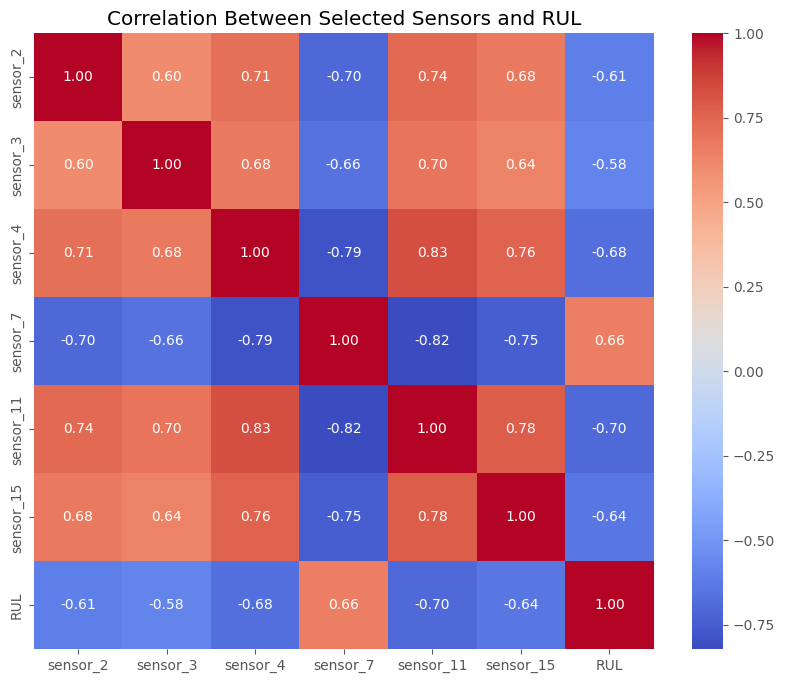

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_columns = [
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_15",
    "RUL"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    working_df[correlation_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Selected Sensors and RUL")

plt.show()

# 17. Sensor Trends Before Maintenance

The following visualisation illustrates how selected sensor values change throughout the engine operating cycles.

These trends provide insight into degradation patterns before engine failure.

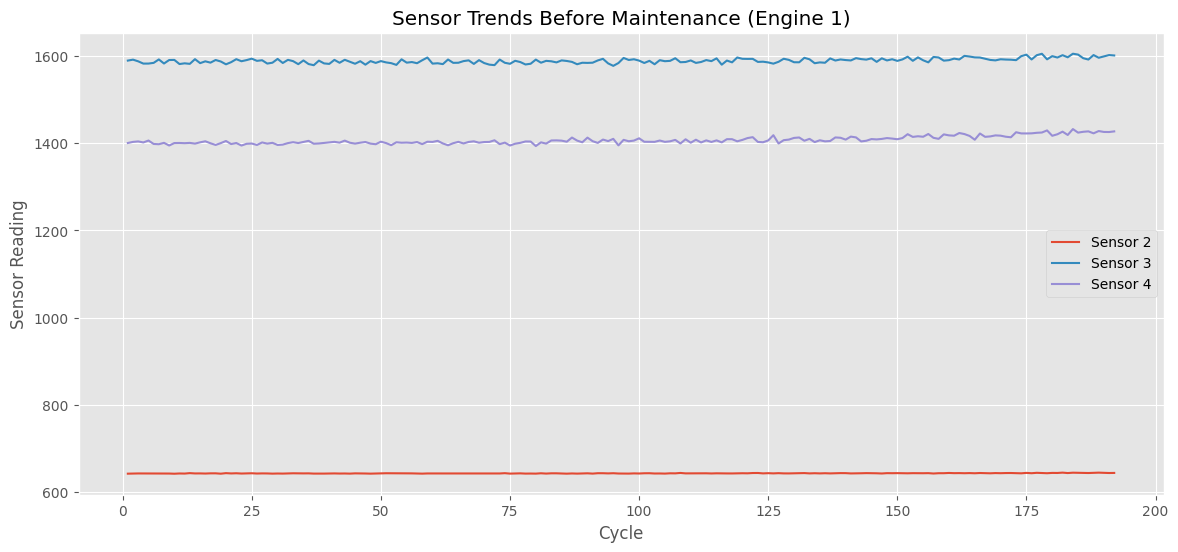

In [35]:
engine_example = 1

engine_df = working_df[
    working_df["engine_id"] == engine_example
]

plt.figure(figsize=(14,6))

plt.plot(
    engine_df["cycle"],
    engine_df["sensor_2"],
    label="Sensor 2"
)

plt.plot(
    engine_df["cycle"],
    engine_df["sensor_3"],
    label="Sensor 3"
)

plt.plot(
    engine_df["cycle"],
    engine_df["sensor_4"],
    label="Sensor 4"
)

plt.xlabel("Cycle")

plt.ylabel("Sensor Reading")

plt.title("Sensor Trends Before Maintenance (Engine 1)")

plt.legend()

plt.show()

 # 18. Outlier Treatment

Potential outliers identified during the previous stage are treated using the Interquartile Range (IQR) capping technique.

Instead of removing observations, values outside the acceptable range are clipped to the lower or upper IQR boundary.

This preserves the continuity of the time series while reducing the influence of abnormal sensor spikes.

In [36]:
# ============================================
# Outlier Treatment using IQR Capping
# ============================================

treated_df = working_df.copy()

for sensor in sensor_columns:

    Q1 = treated_df[sensor].quantile(0.25)
    Q3 = treated_df[sensor].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    treated_df[sensor] = treated_df[sensor].clip(lower, upper)

print("Outlier treatment completed.")

display(treated_df.head())

Outlier treatment completed.


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18_change,sensor_19_roll_mean,sensor_19_roll_std,sensor_19_change,sensor_20_roll_mean,sensor_20_roll_std,sensor_20_change,sensor_21_roll_mean,sensor_21_roll_std,sensor_21_change
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,0.0,100.0,0.0,0.0,39.060000,0.000000,0.00,23.419000,0.000000,0.0000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,0.0,100.0,0.0,0.0,39.030000,0.042426,-0.06,23.421300,0.003253,0.0046
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,0.0,100.0,0.0,0.0,39.003333,0.055076,-0.05,23.395600,0.044573,-0.0794
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,0.0,100.0,0.0,0.0,38.972500,0.076322,-0.07,23.390175,0.037977,0.0297
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,0.0,100.0,0.0,0.0,38.958000,0.073621,0.02,23.393020,0.033498,0.0305


# 19. Fixed Time Window Features

Manufacturing systems often analyse machine behaviour over fixed operating windows rather than individual observations.

A rolling 10-cycle window is used to calculate summary statistics for each engine.

In [37]:
window_size = 10

for sensor in sensor_columns:

    treated_df[f"{sensor}_window_mean"] = (

        treated_df

        .groupby("engine_id")[sensor]

        .transform(

            lambda x:

            x.rolling(window_size,

                      min_periods=1).mean()

        )

    )

# 20. Engine Health Index

A composite Engine Health Index is calculated by averaging the normalised sensor readings.

Lower values indicate healthier operating conditions, while higher values indicate increasing degradation.

In [38]:
treated_df["Engine_Health_Index"] = (

    normalised_df[sensor_columns]

    .mean(axis=1)

)

display(

treated_df[

["engine_id",

"cycle",

"Engine_Health_Index"]

].head()

)

,engine_id,cycle,Engine_Health_Index
0,1,1,0.310556
1,1,2,0.321911
2,1,3,0.305592
3,1,4,0.303568
4,1,5,0.314133


# 21. Engine Risk Classification

Engines are categorised into qualitative maintenance risk levels using Remaining Useful Life.

This classification demonstrates how the processed feature table can support maintenance planning.

In [39]:
def classify_risk(rul):

    if rul < 30:

        return "High"

    elif rul < 80:

        return "Medium"

    else:

        return "Low"

treated_df["Risk_Level"] = (

treated_df["RUL"]

.apply(classify_risk)

)

treated_df[

["engine_id",

"cycle",

"RUL",

"Risk_Level"]

].head()

,engine_id,cycle,RUL,Risk_Level
0,1,1,191,Low
1,1,2,190,Low
2,1,3,189,Low
3,1,4,188,Low
4,1,5,187,Low


#22. Engine Summary Table

In [40]:
engine_summary = (

treated_df

.groupby("engine_id")

.agg(

{

"RUL":"min",

"Engine_Health_Index":"mean",

"Risk_Level":"last"

}

)

.reset_index()

)

display(engine_summary.head())

,engine_id,RUL,Engine_Health_Index,Risk_Level
0,1,0,0.318362,High
1,2,0,0.311008,High
2,3,0,0.324398,High
3,4,0,0.330475,High
4,5,0,0.319398,High


# 23. Pipeline Validation

Before exporting the processed data, the pipeline output is validated.

The following checks are performed:

- Missing values
- Duplicate engine-cycle combinations
- Feature table dimensions
- Risk level distribution
- Engine Health Index range

These validation checks ensure that the processed dataset is ready for downstream maintenance analytics.

In [41]:
# ============================================
# Pipeline Validation
# ============================================

print("=" * 70)
print("PIPELINE VALIDATION")
print("=" * 70)

print(f"Rows                : {treated_df.shape[0]}")
print(f"Columns             : {treated_df.shape[1]}")

print("\nMissing Values")
print(treated_df.isnull().sum().sum())

print("\nDuplicate Engine-Cycle Records")
print(
    treated_df.duplicated(
        subset=["engine_id", "cycle"]
    ).sum()
)

print("\nEngine Health Index")

print("Minimum :", round(treated_df["Engine_Health_Index"].min(),4))
print("Maximum :", round(treated_df["Engine_Health_Index"].max(),4))
print("Average :", round(treated_df["Engine_Health_Index"].mean(),4))

print("\nRisk Level Distribution")

display(
    treated_df["Risk_Level"].value_counts()
)

PIPELINE VALIDATION
Rows                : 20631
Columns             : 117

Missing Values
0

Duplicate Engine-Cycle Records
0

Engine Health Index
Minimum : 0.2178
Maximum : 0.5076
Average : 0.3262

Risk Level Distribution


,count
Risk_Level,
Low,12631
Medium,5000
High,3000


# 24. Final Data Quality Report

A final comparison is presented to demonstrate the improvements achieved through preprocessing.

This report summarises the quality of the dataset before and after pipeline execution.

In [42]:
quality_report = pd.DataFrame({

    "Metric":[

        "Rows",

        "Columns",

        "Missing Values",

        "Duplicate Records",

        "Unique Engines"

    ],

    "Before":[

        df.shape[0],

        df.shape[1],

        df.isnull().sum().sum(),

        df.duplicated().sum(),

        df["engine_id"].nunique()

    ],

    "After":[

        treated_df.shape[0],

        treated_df.shape[1],

        treated_df.isnull().sum().sum(),

        treated_df.duplicated().sum(),

        treated_df["engine_id"].nunique()

    ]

})

display(quality_report)

,Metric,Before,After
0,Rows,20631,20631
1,Columns,26,117
2,Missing Values,0,0
3,Duplicate Records,0,0
4,Unique Engines,100,100


# 25. Export Final Deliverables

The processed outputs are exported for future machine learning and maintenance analysis.

The exported files include:

- Clean sensor dataset
- Engine summary table
- Feature table
- Data quality report

In [43]:
# ============================================
# Export Results
# ============================================

treated_df.to_csv(
    "clean_sensor_dataset.csv",
    index=False
)

engine_summary.to_csv(
    "engine_summary.csv",
    index=False
)

window_summary.to_csv(
    "engine_feature_table.csv"
)

quality_report.to_csv(
    "before_after_quality_report.csv",
    index=False
)

print("All files exported successfully.")

All files exported successfully.


In [44]:
from google.colab import files

files.download("clean_sensor_dataset.csv")
files.download("engine_summary.csv")
files.download("engine_feature_table.csv")
files.download("before_after_quality_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 26. Conclusion

This project successfully developed a complete preprocessing pipeline for manufacturing sensor data using the NASA CMAPSS FD001 dataset.

The pipeline included:

- Data ingestion
- Data inspection
- Machine identifier validation
- Time-series preparation
- Missing value handling
- Sensor normalisation
- Outlier detection and treatment
- Feature engineering
- Fixed time window summarisation
- Engine health scoring
- Maintenance risk classification
- Pipeline validation
- Export of processed datasets

The final outputs provide structured, high-quality feature tables that are suitable for downstream predictive maintenance and autonomous maintenance assistant applications.

No machine learning model was developed, as the focus of this project was the creation of a robust and reusable data preprocessing pipeline.

# 27. Project Summary

This project implemented a complete data preprocessing pipeline for manufacturing predictive maintenance using the NASA CMAPSS FD001 dataset.

The pipeline successfully performed:

- Data ingestion
- Dataset inspection
- Data quality assessment
- Machine identifier validation
- Time-series preparation
- Missing value handling
- Sensor normalisation
- Outlier detection
- Outlier treatment
- Feature engineering
- Fixed time-window summarisation
- Engine health scoring
- Maintenance risk classification
- Pipeline validation
- Export of processed datasets

The resulting feature tables are suitable for downstream predictive maintenance models and autonomous maintenance assistant applications.

# 28. Future Work

The current project focuses exclusively on the preprocessing pipeline.

Future enhancements may include:

- Remaining Useful Life (RUL) prediction using machine learning models.
- Deep learning approaches such as LSTM and Transformer networks for time-series forecasting.
- Real-time sensor streaming using Apache Kafka or MQTT.
- Interactive maintenance dashboards using Power BI or Tableau.
- Cloud deployment using Microsoft Azure, AWS, or Google Cloud Platform.
- Integration with industrial IoT systems for live predictive maintenance.

These enhancements would transform the current preprocessing pipeline into a complete autonomous maintenance system.

# 29. References

1. NASA Prognostics Center of Excellence. Commercial Modular Aero-Propulsion System Simulation (CMAPSS) Dataset.

2. Saxena, A., Goebel, K., Simon, D., & Eklund, N. (2008). Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation.

3. Pandas Documentation:
https://pandas.pydata.org/

4. NumPy Documentation:
https://numpy.org/

5. Scikit-learn Documentation:
https://scikit-learn.org/

6. Matplotlib Documentation:
https://matplotlib.org/

7. Seaborn Documentation:
https://seaborn.pydata.org/

***The processed datasets generated by this pipeline are now suitable for downstream predictive maintenance modelling and autonomous maintenance assistant applications.***